In [1]:
import numpy as np
import joblib
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import load_model

'''
Paso 1 — Carga limpia de todo

Necesitamos cargar:

modelo LSTM
X_test (base del entorno)
x_scaler, y_scaler
feature_cols (importantísimo para índices)
'''


# modelo = 'LSTM_model_v05' #old runs - every 10 minutes
modelo = 'LSTM_model_v11' #old runs - every 10 minutes
sequence_length = 144
H = 12
window_step = 1
window_step_model = 6
# -------------------------
# LOAD MODEL
# -------------------------
model_name = f"{modelo}_{sequence_length}_{H}_step{window_step_model}_EP.keras"

model = load_model(
    f"Trained_Models/{model_name}",
    compile=False
)

# -------------------------
# LOAD SCALERS
# -------------------------
x_scaler = joblib.load(
    f"LSTM_data/{modelo}_scaler_X_train_{sequence_length}_{H}_step{window_step_model}.pkl"
)

dy_scaler = joblib.load(
    f"LSTM_data/{modelo}_scaler_y_train_{sequence_length}_{H}_step{window_step_model}.pkl"
)

# -------------------------
# LOAD DATA
# -------------------------

df_features = pd.read_csv(f'CSV/test_df_{modelo}.csv')
# feature_cols = np.load(f'Features/features_names_{modelo}.npy', allow_pickle=True)
feature_cols = df_features.columns.tolist()


In [2]:
target_col = ['T_confort', 'Humedad_Taller', 'CO2_Taller']

# # Definir variables de entrada
# exclude_cols = (
#     target_col
#     + ['datetime']
# )

# # IMPORTANTE: quitamos o no run_id de las features para que no entre al LSTM como input?
# exo_cols = [c for c in df_features.columns if c not in exclude_cols]
# feature_cols = exo_cols + target_col   # incluyes el pasado del target como input


# feature_cols = df_features.columns.tolist()

print("Num features:", len(feature_cols))

Num features: 98


In [3]:
#checks

assert df_features.shape[1] == len(feature_cols)

idx_temp = feature_cols.index("T_confort")
print("idx_temp:", idx_temp)

idx_temp: 95


In [5]:
# '''
# Paso 2 — Definir la acción del agente

# Vamos a usar una acción continua de dimensión 2:

'''
si el target es solo T_confort, Humedad_Taller, CO2_Taller, entonces quizá no tiene sentido controlar todos los termostatos. 
Para empezar, podríamos controlar solo:

termostatos_Taller_Heating
termostatos_Taller_Cooling

'''

cols_action = [
    "termostatos_Taller_Heating",
    "termostatos_Taller_Cooling"
]

idx_action = [feature_cols.index(c) for c in cols_action]

idx_heat = idx_action[0]
idx_cool = idx_action[1]

print("idx_heat:", idx_heat, feature_cols[idx_heat])
print("idx_cool:", idx_cool, feature_cols[idx_cool])

In [7]:
#Espacio de las acciones heating y cooling en escala real:

heat_min = df_features[feature_cols[idx_heat]].min()
heat_max = df_features[feature_cols[idx_heat]].max()

cool_min = df_features[feature_cols[idx_cool]].min()
cool_max = df_features[feature_cols[idx_cool]].max()

print("Heating range:", heat_min, heat_max)
print("Cooling range:", cool_min, cool_max)


Heating range: 0.0 26.7
Cooling range: 20.0 50.00000000000003


In [8]:
print('Espacio de acciones para heating en escala real:',(heat_min,heat_max))
print('Espacio de acciones para cooling en escala real:',(cool_min,cool_max))

Espacio de acciones para heating en escala real: (np.float64(0.0), np.float64(26.7))
Espacio de acciones para cooling en escala real: (np.float64(20.0), np.float64(50.00000000000003))


In [9]:
'''
Significadod e la escala:

20°C	enfría MUCHO (salta rápido)
24°C	enfría moderado
30°C	enfría poco
50°C	NO enfría

heating ↑ → más calefacción
cooling ↓ → más refrigeración

No son simétricas → esto es importante para el agente

Definiremos rangos físicos razonables: 

heating ∈ [18, 24]
cooling ∈ [22, 28]
'''

#Espacio de acciones reducido
from gymnasium.spaces import Box

action_space = Box(
    low=np.array([18., 24.], dtype=np.float32),
    high=np.array([22., 28.], dtype=np.float32),
    dtype=np.float32
)

In [10]:
# !pip install gymnasium

In [11]:
'''
Paso 3 — Definir los índices de estado que vamos a actualizar

Ahora necesitamos localizar dentro de feature_cols los targets pasados que también están como input:

target_col = ['T_confort', 'Humedad_Taller', 'CO2_Taller']

En el notebook del LSTM hice:

feature_cols = exo_cols + target_col

Entonces estas tres variables están al final de feature_cols.

Estos índices serán necesarios porque, después de que el LSTM prediga el futuro, vamos a reinyectar en la nueva ventana:

T_confort predicha
Humedad_Taller predicha
CO2_Taller predicho
'''

target_col = ['T_confort', 'Humedad_Taller', 'CO2_Taller']

idx_targets_in_X = [feature_cols.index(c) for c in target_col]

idx_T     = idx_targets_in_X[0]
idx_H     = idx_targets_in_X[1]
idx_CO2   = idx_targets_in_X[2]

print("idx_T:", idx_T, feature_cols[idx_T])
print("idx_H:", idx_H, feature_cols[idx_H])
print("idx_CO2:", idx_CO2, feature_cols[idx_CO2])


idx_T: 95 T_confort
idx_H: 96 Humedad_Taller
idx_CO2: 97 CO2_Taller


Haremos lo siguiente: 

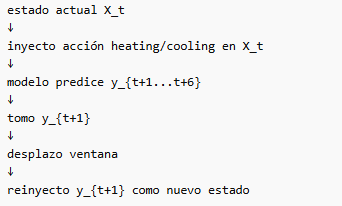

In [12]:
'''
Paso 4 — Función para predecir y recuperar el formato correcto

El modelo devuelve el horizonte aplanado:
(1, H * n_targets)
Necesitamos convertirlo a:
(H, n_targets)
y luego desnormalizarlo.
'''

# -------------------------
# Preparar matriz continua escalada
# -------------------------
X_continuous = df_features[feature_cols].to_numpy(dtype=np.float32)

X_continuous_scaled = x_scaler.transform(
    X_continuous
).astype(np.float32)

# índices de targets dentro de X
idx_targets_in_X = [feature_cols.index(c) for c in target_col]

n_targets = len(target_col)

def predict_horizon_real(model, X, x_scaler, dy_scaler, H, n_targets, idx_targets_in_X):
    """
    X: (1, sequence_length, n_features), escalado con x_scaler

    Devuelve:
        y_abs_real:   (H, n_targets)
        y_abs_scaled: (H, n_targets)
    """

    # 1) Modelo predice deltas escalados
    dy_pred = model.predict(X, verbose=0)

    # Sirve tanto si sale (1, H, n_targets) como si sale (1, H*n_targets)
    dy_scaled = dy_pred.reshape(H, n_targets)

    # 2) Desescalar deltas
    dy_real = dy_scaler.inverse_transform(dy_scaled)

    # 3) Último valor real observado
    y0_scaled = X[0, -1, idx_targets_in_X]

    y0_real = (
        y0_scaled * x_scaler.scale_[idx_targets_in_X]
        + x_scaler.mean_[idx_targets_in_X]
    )

    # 4) Reconstruir valores absolutos reales
    y_abs_real = y0_real + dy_real

    # 5) Reescalar valores absolutos para reinyectar en X
    y_abs_scaled = (
        y_abs_real - x_scaler.mean_[idx_targets_in_X]
    ) / x_scaler.scale_[idx_targets_in_X]

    return y_abs_real.astype(np.float32), y_abs_scaled.astype(np.float32)

'''
Prueba rápida, debería salir:

y_real shape: (12, 3)
y_scaled shape: (12, 3)

'''
start_idx = 0

X0 = X_continuous_scaled[
    start_idx : start_idx + sequence_length
].copy()

X0 = X0[None, :, :]  # (1, 144, 110)

y_real, y_scaled = predict_horizon_real(
    model,
    X0,
    x_scaler,
    dy_scaler,
    H,
    n_targets,
    idx_targets_in_X
)

print("X0 shape:", X0.shape)
print("y_real shape:", y_real.shape)
print("y_scaled shape:", y_scaled.shape)

print("Primera predicción t+1:")
for name, value in zip(target_col, y_real[0]):
    print(name, value)

X0 shape: (1, 144, 98)
y_real shape: (12, 3)
y_scaled shape: (12, 3)
Primera predicción t+1:
T_confort 19.698036
Humedad_Taller 43.554424
CO2_Taller 400.76007


In [13]:
'''
Paso 5 — Función para escribir la acción en la ventana

Ahora necesitamos modificar la ventana X antes de pasársela al LSTM.

La acción es:
action = [heating_Taller, cooling_Taller]
ambas en escala 0..1.
'''

def write_action_into_last_step(X, action, idx_heat, idx_cool, x_scaler):
    X_new = X.copy()

    # acción ya en escala real
    a_heat = float(action[0])
    a_cool = float(action[1])

    # escalar para meter en X
    heat_scaled = (a_heat - x_scaler.mean_[idx_heat]) / x_scaler.scale_[idx_heat]
    cool_scaled = (a_cool - x_scaler.mean_[idx_cool]) / x_scaler.scale_[idx_cool]

    X_new[0, -1, idx_heat] = heat_scaled
    X_new[0, -1, idx_cool] = cool_scaled

    return X_new

#Pueba
# -------------------------
# Ventana inicial desde serie continua
# -------------------------
start_idx = 0

X0 = X_continuous_scaled[
    start_idx : start_idx + sequence_length
].copy()

# agregar dimensión batch
X0 = X0[None, :, :]   # (1, 144, 110)

# -------------------------
# Acción PPO en escala real
# -------------------------
action = np.array([20.0, 30.0], dtype=np.float32)
# -------------------------
# Escribir acción
# -------------------------
X_action = write_action_into_last_step(
    X0,
    action,
    idx_heat,
    idx_cool,
    x_scaler
)

print("Antes:")
print(
    X0[0, -1, idx_heat],
    X0[0, -1, idx_cool]
)

print("Después:")
print(
    X_action[0, -1, idx_heat],
    X_action[0, -1, idx_cool]
)

Antes:
-0.17257802 -1.0561736
Después:
0.27398846 -0.11565939


In [14]:
heat_real_before = (
    X0[0, -1, idx_heat] * x_scaler.scale_[idx_heat]
    + x_scaler.mean_[idx_heat]
)

cool_real_before = (
    X0[0, -1, idx_cool] * x_scaler.scale_[idx_cool]
    + x_scaler.mean_[idx_cool]
)

heat_real_after = (
    X_action[0, -1, idx_heat] * x_scaler.scale_[idx_heat]
    + x_scaler.mean_[idx_heat]
)

cool_real_after = (
    X_action[0, -1, idx_cool] * x_scaler.scale_[idx_cool]
    + x_scaler.mean_[idx_cool]
)

print("\nReal values:")
print("Before:", heat_real_before, cool_real_before)
print("After :", heat_real_after, cool_real_after)


Real values:
Before: 16.000000074332494 20.000000514749573
After : 19.999999947841808 29.999999980776916


In [15]:
'''
Paso 6 — Desplazar la ventana y reinyectar el estado predicho

Después de predecir, necesitamos construir el siguiente estado del entorno.

La lógica es:

X actual:      [t-11, t-10, ..., t]
acción en t
LSTM predice: [t+1, ..., t+6]
nuevo X:      [t-10, ..., t, t+1]

Para eso usamos solo la predicción de t+1:

y_next_scaled = y_pred_scaled[0]

porque y_pred_scaled tiene forma:

(H, n_targets)
'''

def shift_window_and_inject_prediction(
    X,
    next_row_scaled,
    y_next_scaled,
    idx_targets_in_X,
    action=None,
    idx_heat=None,
    idx_cool=None,
    x_scaler=None
):
    """
    X:               (1, T, F) normalizado
    next_row_scaled: (F,) fila futura real del df_features continuo, ya escalada
    y_next_scaled:   (n_targets,) targets predichos en escala X
    """

    X_new = X.copy()

    # desplazar 1 timestep = 10 min
    X_new[0, :-1, :] = X_new[0, 1:, :]

    # meter fila futura real: clima, hora, ocupación, radiación, etc.
    X_new[0, -1, :] = next_row_scaled.copy()

    # reinyectar targets predichos
    for j, idx in enumerate(idx_targets_in_X):
        X_new[0, -1, idx] = y_next_scaled[j]

    # opcional: reinyectar acción PPO también en el nuevo timestep
    if action is not None:
        heat_scaled = (float(action[0]) - x_scaler.mean_[idx_heat]) / x_scaler.scale_[idx_heat]
        cool_scaled = (float(action[1]) - x_scaler.mean_[idx_cool]) / x_scaler.scale_[idx_cool]

        X_new[0, -1, idx_heat] = heat_scaled
        X_new[0, -1, idx_cool] = cool_scaled

    return X_new

In [16]:
idx = start_idx

# fila futura real t+1
next_row_scaled = X_continuous_scaled[idx + sequence_length].copy()

y_next_scaled = y_scaled[0]

X_next = shift_window_and_inject_prediction(
    X_action,
    next_row_scaled,
    y_next_scaled,
    idx_targets_in_X,
    action=action,
    idx_heat=idx_heat,
    idx_cool=idx_cool,
    x_scaler=x_scaler
)

idx += 1

In [17]:
# prueba rápida

start_idx = 0

# ventana inicial desde serie continua
X0 = X_continuous_scaled[
    start_idx : start_idx + sequence_length
].copy()

X0 = X0[None, :, :]   # (1, 144, 110)

action = np.array([20.0, 30.0], dtype=np.float32)

print("X0 shape:", X0.shape)

# escribir acción en último timestep
X_action = write_action_into_last_step(
    X0,
    action,
    idx_heat,
    idx_cool,
    x_scaler
)

# predecir horizonte
y_real, y_scaled = predict_horizon_real(
    model,
    X_action,
    x_scaler,
    dy_scaler,
    H,
    n_targets,
    idx_targets_in_X
)

# fila futura real del dataframe continuo: t+1
next_row_scaled = X_continuous_scaled[
    start_idx + sequence_length
].copy()

# desplazar ventana e inyectar predicción t+1
X_next = shift_window_and_inject_prediction(
    X_action,
    next_row_scaled,
    y_scaled[0],
    idx_targets_in_X,
    action=action,
    idx_heat=idx_heat,
    idx_cool=idx_cool,
    x_scaler=x_scaler
)

print("X_next shape:", X_next.shape)

print("n_features:", X0.shape[2])
print("idx_targets_in_X:", idx_targets_in_X)
print("max idx:", max(idx_targets_in_X))

print("Targets reinyectados en último timestep:")
for j, name in enumerate(target_col):
    idx = idx_targets_in_X[j]
    print(name, X_next[0, -1, idx], "| pred:", y_scaled[0, j])

X0 shape: (1, 144, 98)
X_next shape: (1, 144, 98)
n_features: 98
idx_targets_in_X: [95, 96, 97]
max idx: 97
Targets reinyectados en último timestep:
T_confort -0.93421364 | pred: -0.93421364
Humedad_Taller -0.37415513 | pred: -0.37415513
CO2_Taller -0.8204439 | pred: -0.8204439


In [18]:
print("Predicción real t+1:")
for name, value in zip(target_col, y_real[0]):
    print(name, value)

print("\nPredicción escalada reinyectada:")
for name, value in zip(target_col, y_scaled[0]):
    print(name, value)

Predicción real t+1:
T_confort 19.706106
Humedad_Taller 43.567062
CO2_Taller 401.16492

Predicción escalada reinyectada:
T_confort -0.93421364
Humedad_Taller -0.37415513
CO2_Taller -0.8204439


### Cómo entrena el agente?

El entorno es:

LSTM (modelo del edificio) + reward

Entonces el loop es:

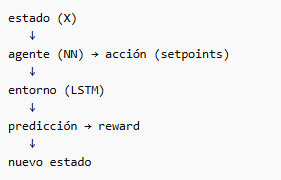

Esto ocurre MUCHAS veces

#### En PPO (Proximal Policy Optimization):

El agente ejecuta la política actual

Recolecta datos:

(estado, acción, reward, siguiente estado)
Junta muchos pasos (ej: 2048 steps)
Luego:
- actualiza la red neuronal


- La red NO se actualiza en cada step
- Se actualiza después de acumular experiencia


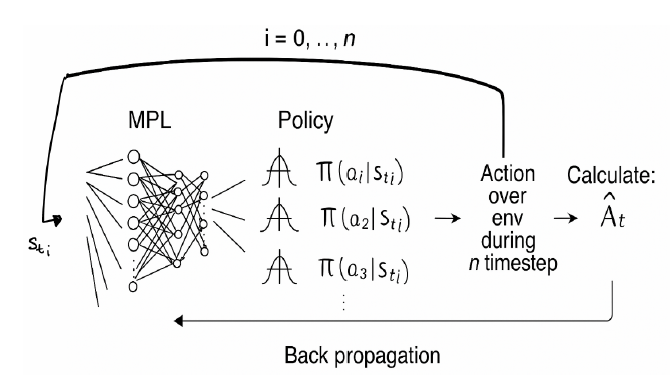

\begin{equation}
V(s): \text{ value, el valor que estima el critico para predecir el reward }
\end{equation}

\begin{equation}
\delta_t
=
r_t
+
\gamma V(s_{t+1})
-
V(s_t)
\end{equation}

\begin{equation}
\hat{A}_t
=
\delta_t
+
(\gamma \lambda)\delta_{t+1}
+
(\gamma \lambda)^2 \delta_{t+2}
+\dots
\end{equation}

\begin{equation}
r_t: \text{es el reward inmediato recibido en el timestep } t
\end{equation}

\begin{equation}
V(s)
=
\mathbb{E}_{\pi}
\left[
G_t
\mid
s_t=s
\right]
\end{equation}

\begin{equation}
G_t
=
r_t
+
\gamma r_{t+1}
+
\gamma^2 r_{t+2}
+\dots
\end{equation}

\begin{equation}
\mathrm{ExplainedVariance}
=
1-
\frac{
\mathrm{Var}(y-\hat{y})
}{
\mathrm{Var}(y)
}
\end{equation}



## Explicado:

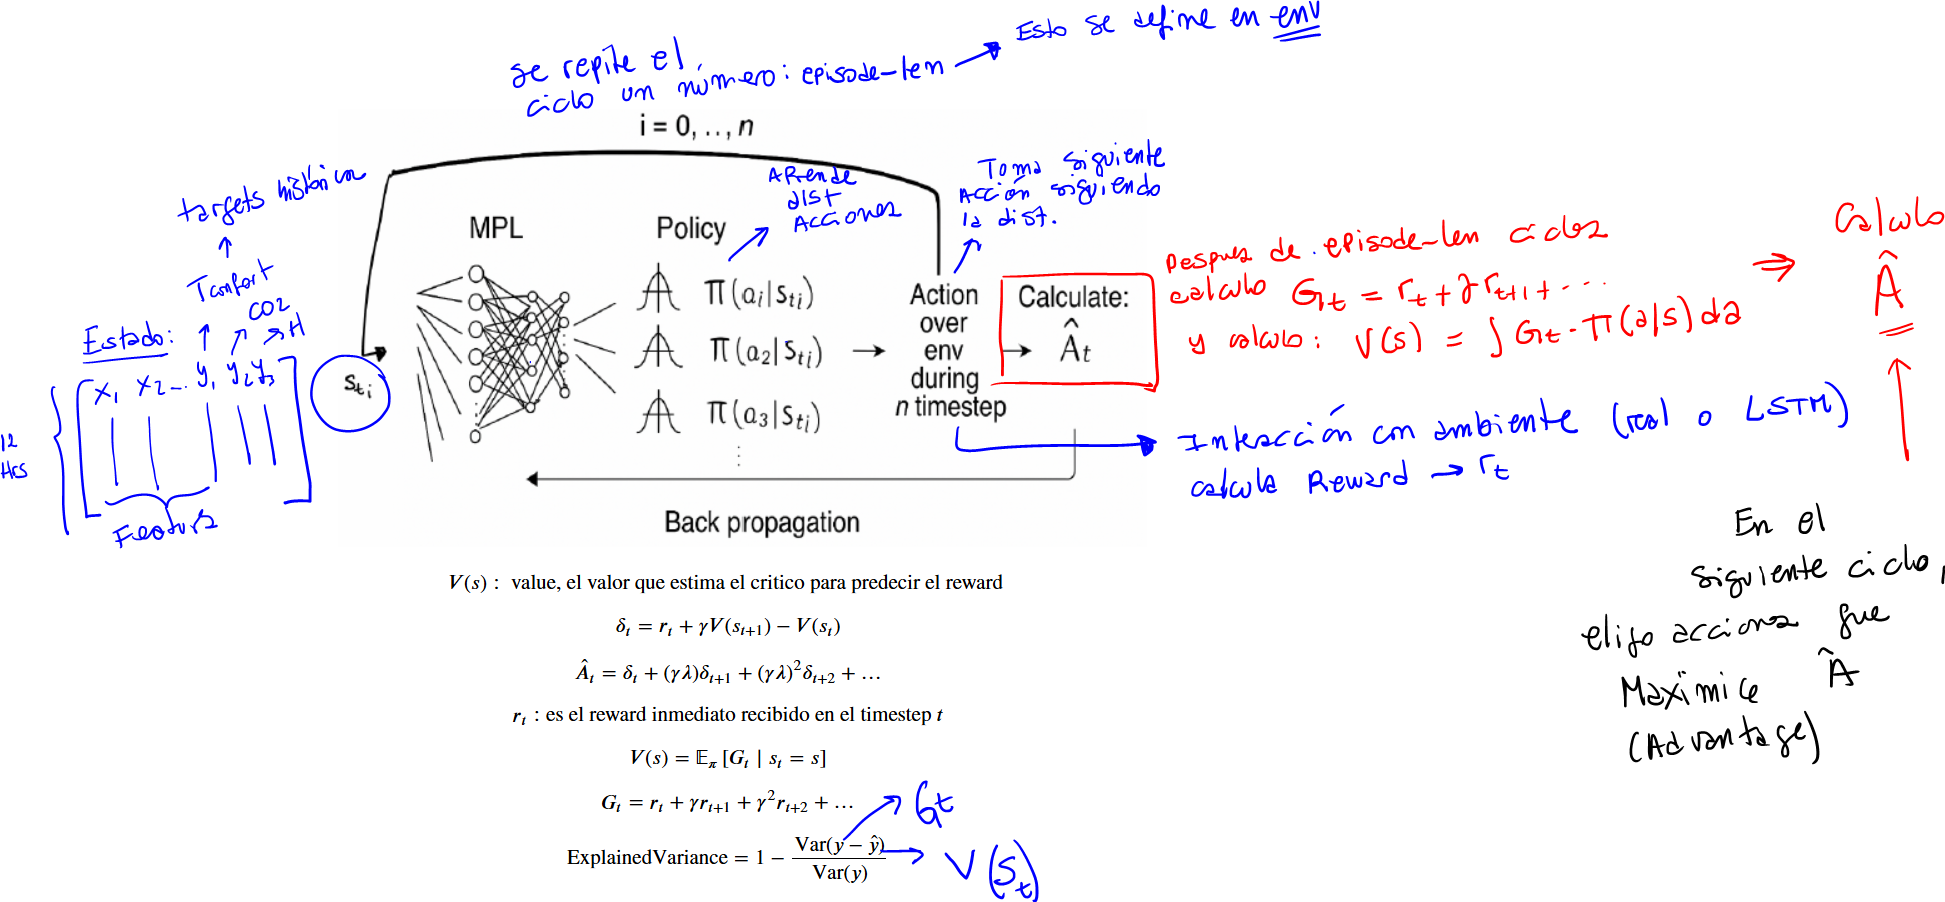

In [508]:

def compute_reward(
    y_next_real,
    action,
    target_col,
    prev_action=None,
    dT=0.0,
    comfort_T=(20.0, 26.0),
    T_ideal=23.0,
    comfort_RH=(30.0, 70.0),
    RH_ideal=50.0,
    max_CO2=1000.0,
    min_deadband=2.0,
    w_T_band=100.0,
    w_T_ideal=1.0,
    w_RH_band=2.0,
    w_RH_ideal=0.01,
    w_CO2=0.0005,
    w_energy=0.2,
    w_deadband_invalid=0.5,
    w_deadband_narrow=0.2,
    w_smooth=0.1,
    w_useless_action=0.5,
    w_trend = 1.0
):
    values = dict(zip(target_col, y_next_real))

    T = float(values["T_confort"])
    RH = float(values["Humedad_Taller"])
    CO2 = float(values["CO2_Taller"])

    heat_sp = float(action[0])
    cool_sp = float(action[1])

    # -------------------------
    # 1. Confort térmico
    # -------------------------
    T_low, T_high = comfort_T

    T_band_pen = max(T_low - T, 0.0) + max(T - T_high, 0.0)
    T_ideal_pen = T - T_ideal

    trend_penalty = 0.0
    # demasiado frío y bajando
    if T < T_low and dT < 0:
        trend_penalty += abs(dT) * 5.0

    # demasiado caliente y subiendo
    if T > T_high and dT > 0:
        trend_penalty += abs(dT) * 5.0
    

    # -------------------------
    # 2. Humedad y CO2
    # -------------------------
    RH_low, RH_high = comfort_RH

    RH_band_pen = max(RH_low - RH, 0.0) + max(RH - RH_high, 0.0)
    RH_ideal_pen = RH - RH_ideal

    CO2_pen = max(CO2 - max_CO2, 0.0)

    # -------------------------
    # 3. Esfuerzo HVAC físico
    # Heating activo si T < heat_sp
    # Cooling activo si T > cool_sp
    # -------------------------
    heating_effort = max(heat_sp - T, 0.0)
    cooling_effort = max(T - cool_sp, 0.0)

    energy_pen = heating_effort**2 + cooling_effort**2

    # -------------------------
    # 4. Deadband físicamente válida
    # heat_sp debe ser menor que cool_sp
    # y debe haber una separación mínima
    # -------------------------
    deadband_width = cool_sp - heat_sp

    deadband_invalid_pen = max(heat_sp - cool_sp, 0.0)**2
    deadband_narrow_pen = max(min_deadband - deadband_width, 0.0)**2

    # -------------------------
    # 5. Penalización por acciones bruscas
    # -------------------------
    if prev_action is not None:
        prev_heat = float(prev_action[0])
        prev_cool = float(prev_action[1])

        smooth_pen = (heat_sp - prev_heat)**2 + (cool_sp - prev_cool)**2
    else:
        smooth_pen = 0.0
    
    
    # -------------------------
    # 6. Penalización por acción inútil
    # Si T está por debajo de confort, no tiene sentido cooling bajo.
    # Si T está por encima de confort, no tiene sentido heating alto.
    # -------------------------
    useless_cooling_pen = 0.0
    useless_heating_pen = 0.0

    if T < T_low:
        useless_cooling_pen = max(T_high - cool_sp, 0.0)**2

    if T > T_high:
        useless_heating_pen = max(heat_sp - T_low, 0.0)**2

    useless_action_pen = useless_cooling_pen + useless_heating_pen

    # -------------------------
    # Loss total
    # -------------------------
#     loss = (
#         w_T_band * T_band_pen**2
#         + w_T_ideal * T_ideal_pen**2
#         + w_RH_band * RH_band_pen**2
#         + w_RH_ideal * RH_ideal_pen**2
#         + w_CO2 * CO2_pen**2
#         + w_energy * energy_pen
#         + w_deadband_invalid * deadband_invalid_pen
#         + w_deadband_narrow * deadband_narrow_pen
#         + w_smooth * smooth_pen
#         + w_useless_action * useless_action_pen
#     )

#     # Loss simple
#     loss = T_band_pen**2 #NO funciona. Critico muy inestable

    #Hata ahora el mejor Loss
    loss = (
            w_T_band * T_band_pen**2
            + w_energy * energy_pen
            + w_smooth * smooth_pen
            + w_trend * trend_penalty
        )
    
      #Segundo mejor Loss
#     loss = (
#             w_T_band * T_band_pen**2
#             + w_energy * energy_pen
#             + w_smooth * smooth_pen
#             + w_trend * trend_penalty
#             #Terminos nuevos: #cuando los agrego el PPO funciona peor
#             + w_T_ideal * T_ideal_pen**2
#             + w_deadband_invalid * deadband_invalid_pen
#             + w_deadband_narrow * deadband_narrow_pen
#             + w_useless_action * useless_action_pen
#         )




#     reward = -loss / 1000.0 #Mal escalada, el agente no cambia las acciones, se queda siempre igual, el reward es bajo
#     reward = -loss #Mal escalado, reward demasiado grande
    reward = -loss / 100.0
    
    info_reward = {
        "T": T,
        "RH": RH,
        "CO2": CO2,
        "heat_sp": heat_sp,
        "cool_sp": cool_sp,
        "T_band_pen": T_band_pen,
        "T_ideal_pen": T_ideal_pen,
        "RH_band_pen": RH_band_pen,
        "RH_ideal_pen": RH_ideal_pen,
        "CO2_pen": CO2_pen,
        "heating_effort": heating_effort,
        "cooling_effort": cooling_effort,
        "energy_pen": energy_pen,
        "deadband_width": deadband_width,
        "deadband_invalid_pen": deadband_invalid_pen,
        "deadband_narrow_pen": deadband_narrow_pen,
        "smooth_pen": smooth_pen,
        "useless_cooling_pen": useless_cooling_pen,
        "useless_heating_pen": useless_heating_pen,
        "useless_action_pen": useless_action_pen,
        "loss": loss,
        "reward": reward,
    }

    return float(reward), info_reward



In [509]:
# Prueba reward
y_next_real = y_real[0]

for action in [
    np.array([20, 2.5], dtype=np.float32),
    np.array([24, 2.5], dtype=np.float32),
    np.array([18, 2.5], dtype=np.float32),
    np.array([25, 2.5], dtype=np.float32),  # contradictoria
]:

    reward, info = compute_reward(
        y_next_real=y_next_real,
        action=action,
        target_col=target_col,
        dT = -1
    )

    print("Action:", action)
    print("Reward:", reward)
    print(info)
    print()

Action: [20.   2.5]
Reward: -0.7306785083172727
{'T': 19.702228546142578, 'RH': 43.56366729736328, 'CO2': 401.019775390625, 'heat_sp': 20.0, 'cool_sp': 2.5, 'T_band_pen': 0.2977714538574219, 'T_ideal_pen': -3.297771453857422, 'RH_band_pen': 0.0, 'RH_ideal_pen': -6.436332702636719, 'CO2_pen': 0.0, 'heating_effort': 0.2977714538574219, 'cooling_effort': 17.202228546142578, 'energy_pen': 296.00533479245496, 'deadband_width': -17.5, 'deadband_invalid_pen': 306.25, 'deadband_narrow_pen': 380.25, 'smooth_pen': 0.0, 'useless_cooling_pen': 552.25, 'useless_heating_pen': 0.0, 'useless_action_pen': 552.25, 'loss': 73.06785083172727, 'reward': -0.7306785083172727}

Action: [24.   2.5]
Reward: -0.7674428515789914
{'T': 19.702228546142578, 'RH': 43.56366729736328, 'CO2': 401.019775390625, 'heat_sp': 24.0, 'cool_sp': 2.5, 'T_band_pen': 0.2977714538574219, 'T_ideal_pen': -3.297771453857422, 'RH_band_pen': 0.0, 'RH_ideal_pen': -6.436332702636719, 'CO2_pen': 0.0, 'heating_effort': 4.297771453857422, 'c

In [462]:
'''
La lógica es:

reward = - pérdida

Entonces PPO intentará maximizar reward, que equivale a minimizar disconfort + energía.
'''

'\nLa lógica es:\n\nreward = - pérdida\n\nEntonces PPO intentará maximizar reward, que equivale a minimizar disconfort + energía.\n'

In [463]:
'''
Paso 8 — Construir el entorno Gymnasium completo

Ahora juntamos lo anterior en una clase Env.
'''

'\nPaso 8 — Construir el entorno Gymnasium completo\n\nAhora juntamos lo anterior en una clase Env.\n'

In [510]:
'''
Esta versión elimina heat_bounds y cool_bounds, y usa center_bounds + deadband_bounds. 
Esto es para evitar tener acciones absurdas.
'''

import gymnasium as gym
from gymnasium import Env
from gymnasium.spaces import Box
import numpy as np


class ComfortTallerEnv(Env):
    def __init__(
        self,
        X_continuous_scaled,
        model,
        x_scaler,
        dy_scaler,
        feature_cols,
        target_col,
        idx_heat,
        idx_cool,
        idx_targets_in_X,
        sequence_length,
        H,
        episode_len=144,
        center_bounds=(21.0, 25.0),
        deadband_bounds=(3.0, 5.0),
    ):
        super().__init__()

        self.X_data = X_continuous_scaled.astype(np.float32)
        self.model = model
        self.x_scaler = x_scaler
        self.dy_scaler = dy_scaler
        self.feature_cols = feature_cols
        self.target_col = target_col

        self.idx_heat = idx_heat
        self.idx_cool = idx_cool
        self.idx_targets_in_X = idx_targets_in_X

        self.sequence_length = sequence_length
        self.H = H
        self.n_targets = len(target_col)
        self.episode_len = episode_len

        self.center_bounds = center_bounds
        self.deadband_bounds = deadband_bounds

        F = self.X_data.shape[1]

        self.observation_space = Box(
            low=-np.inf,
            high=np.inf,
            shape=(sequence_length, F),
            dtype=np.float32
        )

        self.action_space = Box(
            low=np.array(
                [self.center_bounds[0], self.deadband_bounds[0]],
                dtype=np.float32
            ),
            high=np.array(
                [self.center_bounds[1], self.deadband_bounds[1]],
                dtype=np.float32
            ),
            dtype=np.float32
        )

        self.X = None
        self.current_idx = None
        self.t = 0
        self.prev_action = None
        self.prev_T = None

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        max_start = len(self.X_data) - self.sequence_length - self.episode_len - 1
        start_idx = int(self.np_random.integers(0, max_start))

        self.current_idx = start_idx

        self.X = self.X_data[
            start_idx : start_idx + self.sequence_length
        ].copy()

        self.X = self.X[None, :, :]

        self.t = 0
        self.prev_action = None
        self.prev_T = None

        obs = self.X[0].astype(np.float32)

        return obs, {}

    def step(self, action):
        action = np.asarray(action, dtype=np.float32)

        center = float(np.clip(
            action[0],
            self.center_bounds[0],
            self.center_bounds[1]
        ))

        deadband = float(np.clip(
            action[1],
            self.deadband_bounds[0],
            self.deadband_bounds[1]
        ))

        heat_sp = center - deadband / 2.0
        cool_sp = center + deadband / 2.0

        action_physical = np.array([heat_sp, cool_sp], dtype=np.float32)

        # 1) escribir acción física en último timestep
        X_action = write_action_into_last_step(
            self.X,
            action_physical,
            self.idx_heat,
            self.idx_cool,
            self.x_scaler
        )

        # 2) predecir horizonte
        y_real, y_scaled = predict_horizon_real(
            self.model,
            X_action,
            self.x_scaler,
            self.dy_scaler,
            self.H,
            self.n_targets,
            self.idx_targets_in_X
        )

        # 3) usar solo t+1
        y_next_real = y_real[0]
        y_next_scaled = y_scaled[0]
        
        idx_T = self.target_col.index("T_confort")
        T = float(y_next_real[idx_T])

        if self.prev_T is None:
            dT = 0.0
        else:
            dT = T - self.prev_T

        # 4) reward
        reward, info_reward = compute_reward(
            y_next_real=y_next_real,
            action=action_physical,
            target_col=self.target_col,
            prev_action=self.prev_action,
            dT = dT
        )
        
        self.prev_T = T

        # 5) fila futura real del df continuo
        next_row_idx = self.current_idx + self.sequence_length
        next_row_scaled = self.X_data[next_row_idx].copy()

        # 6) shift + append + inyección
        self.X = shift_window_and_inject_prediction(
            X_action,
            next_row_scaled,
            y_next_scaled,
            self.idx_targets_in_X,
            action=action_physical,
            idx_heat=self.idx_heat,
            idx_cool=self.idx_cool,
            x_scaler=self.x_scaler
        )

        self.prev_action = action_physical.copy()

        # 7) avanzar un timestep real = 10 min
        self.current_idx += 1
        self.t += 1

        terminated = self.t >= self.episode_len
        truncated = False

        obs = self.X[0].astype(np.float32)

        info = {
            **info_reward,
            "action_center": center,
            "action_deadband": deadband,
            "action_heat": heat_sp,
            "action_cool": cool_sp,
            "current_idx": self.current_idx,
            "step": self.t,
        }

        return obs, float(reward), terminated, truncated, info

In [511]:
#Crear entorno

# Crear entorno PPO

env = ComfortTallerEnv(
    X_continuous_scaled=X_continuous_scaled,
    model=model,
    x_scaler=x_scaler,
    dy_scaler=dy_scaler,
    feature_cols=feature_cols,
    target_col=target_col,
    idx_heat=idx_heat,
    idx_cool=idx_cool,
    idx_targets_in_X=idx_targets_in_X,
    sequence_length=sequence_length,
    H=H,
    episode_len=90   # Para pasar a hrs dividir por 6. 40 -> 6.7 hrs. 
)

In [512]:
'''
Paso 9 — Rollout manual del entorno: Aun no tenemos el PPO, solo estamos sampleando acciones de manera aleatorea
'''

obs, _ = env.reset()

temps = []
rhs = []
co2s = []

heats = []
cools = []

centers = []
deadbands = []

rewards = []

for t in range(env.episode_len):

    # acción random:
    # action[0] = center
    # action[1] = deadband
    action = env.action_space.sample()

    obs, reward, terminated, truncated, info = env.step(action)

    # variables predichas
    temps.append(info["T"])
    rhs.append(info["RH"])
    co2s.append(info["CO2"])

    # acciones físicas HVAC
    heats.append(info["action_heat"])
    cools.append(info["action_cool"])

    # acciones RL
    centers.append(info["action_center"])
    deadbands.append(info["action_deadband"])

    # reward
    rewards.append(reward)

    if terminated or truncated:
        break

print("Rollout length:", len(temps))
print("Final T:", temps[-1])
print("Final reward:", rewards[-1])

print("Final heat_sp:", heats[-1])
print("Final cool_sp:", cools[-1])

print("Final center:", centers[-1])
print("Final deadband:", deadbands[-1])

Rollout length: 90
Final T: 19.372295379638672
Final reward: -0.4264230994546888
Final heat_sp: 22.802533984184265
Final cool_sp: 26.792299389839172
Final center: 24.79741668701172
Final deadband: 3.9897654056549072


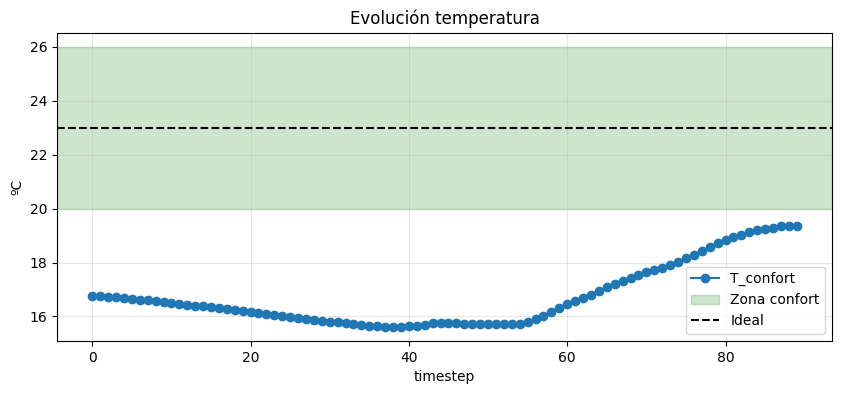

In [513]:
#Plot Temperatura
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(temps, marker='o', label="T_confort")

plt.axhspan(20, 26, color='green', alpha=0.2, label="Zona confort")
plt.axhline(23, linestyle='--', color='black', label="Ideal")

plt.title("Evolución temperatura")
plt.ylabel("ºC")
plt.xlabel("timestep")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

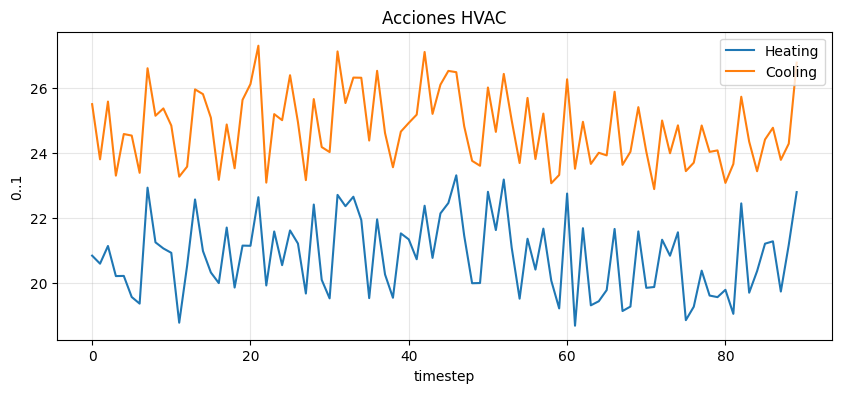

In [514]:
#Plot Acciones
plt.figure(figsize=(10,4))
plt.plot(heats, label="Heating")
plt.plot(cools, label="Cooling")

plt.title("Acciones HVAC")
plt.ylabel("0..1")
plt.xlabel("timestep")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

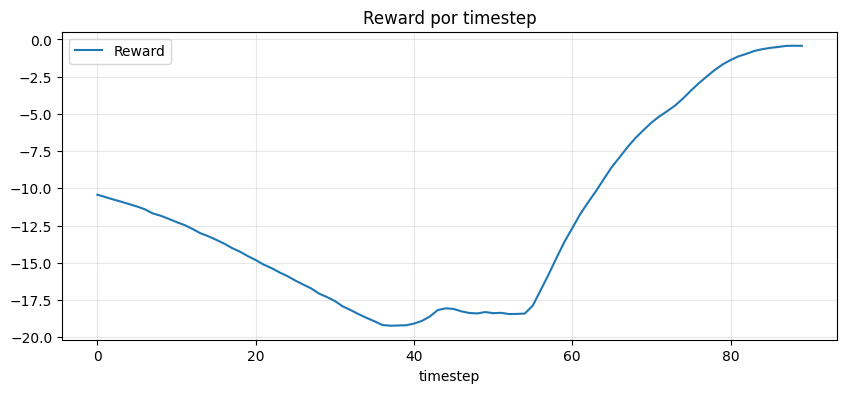

In [515]:
#Plot Reward

plt.figure(figsize=(10,4))
plt.plot(rewards, label="Reward")

plt.title("Reward por timestep")
plt.xlabel("timestep")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### PPO

In [516]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

check_env(env, warn=True)


ppo_model = PPO(
    policy="MlpPolicy",
    env=env,
    learning_rate=1e-4, #probar: 5e-5
    n_steps=512,
    batch_size=64,#probar 128
    n_epochs=20,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.1,
    ent_coef=0.01,
    verbose=1,
)

C:\Users\Ana\anaconda3\envs\rl_energyplus\lib\site-packages\stable_baselines3\common\env_checker.py:324: UserWarning: Your observation  has an unconventional shape (neither an image, nor a 1D vector). We recommend you to flatten the observation to have only a 1D vector or use a custom policy to properly process the data.
  warnings.warn(
C:\Users\Ana\anaconda3\envs\rl_energyplus\lib\site-packages\stable_baselines3\common\env_checker.py:515: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


En PPO existen dos componentes principales:

- Actor (policy): aprende qué acción tomar en cada estado.
- Crítico (value network): aprende qué tan bueno es un estado en términos de reward futuro esperado.


La política aprende una función:

\begin{equation}
\pi(a \mid s)
\end{equation}

que representa la probabilidad de tomar una acción $a$ dado un estado $s$.

Por otro lado, el crítico aprende la función de valor:

\begin{equation}
V(s)
\end{equation}

que estima el retorno acumulado esperado futuro desde el estado actual.

La *explained variance* mide qué tan bien el crítico predice esos retornos futuros reales.

Se calcula mediante:

\begin{equation}
\mathrm{ExplainedVariance}
=
1-
\frac{
\mathrm{Var}(y-\hat{y})
}{
\mathrm{Var}(y)
}
\end{equation}

donde:

- $y$ representa el retorno acumulado real observado durante el rollout.
- $\hat{y}$ representa la predicción realizada por el crítico.


Interpretación:

- $\mathrm{ExplainedVariance} \approx 1$: el crítico predice muy bien los retornos.
-  $\mathrm{ExplainedVariance} \approx 0$: el crítico prácticamente no aprende información útil.
- $\mathrm{ExplainedVariance} < 0$: el crítico predice peor que usar simplemente el promedio.


Es importante notar que:

\begin{equation}
\hat{y} \neq \text{predicción del LSTM del entorno}
\end{equation}

El LSTM del entorno predice la dinámica física del sistema:

\begin{equation}
(s_t, a_t)
\rightarrow
s_{t+1}
\end{equation}

por ejemplo temperatura, humedad o CO$_2$ futuros.

En cambio, el crítico de PPO predice:

\begin{equation}
V(s_t)
\end{equation}

es decir, cuánto reward acumulado espera obtener el agente desde el estado actual.

In [517]:
'''
policy="MlpPolicy"
--------------------
Define la arquitectura de la política y del crítico.

"MlpPolicy" utiliza redes neuronales feedforward (MLP).
La red recibe el estado como input y produce:

- la acción del actor,
- y la estimación V(s) del crítico.


env=env
-------
Entorno con el que interactúa PPO.

El entorno define:

- estados,
- acciones,
- reward,
- dinámica de transición.


learning_rate=1e-4
------------------
Tasa de aprendizaje del optimizador.

Controla cuánto cambian los pesos en cada update.

- Valores altos:
    aprendizaje más rápido pero más inestable.
- Valores bajos:
    aprendizaje más lento pero más estable.


n_steps=512
-----------
Cantidad de interacciones que PPO recolecta antes de actualizar la política.

PPO:
1. ejecuta 512 pasos en el entorno,
2. almacena transiciones,
3. calcula returns y advantages,
4. entrena actor y crítico.

En este caso:
512 pasos × 10 min ≈ 85 horas simuladas
(repartidas entre múltiples episodios).


batch_size=64
-------------
Tamaño de minibatch usado durante entrenamiento.

Los 512 samples se dividen en batches de 64.

Entonces:
512 / 64 = 8 minibatches por época.


n_epochs=20
-----------
Cantidad de veces que PPO reutiliza los mismos datos recolectados.

Después de recolectar 512 pasos,
PPO entrena durante 20 épocas completas.

Updates totales por rollout:
20 × 8 = 160 updates.


gamma=0.99
-----------
Factor de descuento temporal.

Define cuánto importan las recompensas futuras.

Retorno:

G_t = r_t + gamma*r_{t+1} + gamma^2*r_{t+2} + ...

- gamma cercano a 1:
    comportamiento más a largo plazo.
- gamma pequeño:
    comportamiento más miope.


gae_lambda=0.95
----------------
Parámetro de Generalized Advantage Estimation (GAE).

Controla el trade-off entre:

- bias,
- varianza

en la estimación de ventajas.

- Valores altos:
    menos bias, más varianza.
- Valores bajos:
    más estabilidad, más bias.


clip_range=0.1
---------------
Parámetro central de PPO.

Limita cuánto puede cambiar la política en un update.

PPO restringe:

pi_new(a|s) / pi_old(a|s)

para evitar cambios demasiado grandes.

Con clip_range=0.1:
la política puede cambiar aproximadamente ±10%.

- pequeño:
    más estabilidad.
- grande:
    updates más agresivos.


ent_coef=0.01
--------------
Coeficiente de entropía.

Incentiva exploración.

- entropía alta:
    acciones más aleatorias.
- entropía baja:
    política más determinista.

Si ent_coef es alto:
el agente explora más.


verbose=1
----------
Nivel de logs mostrados durante entrenamiento.

0 -> silencioso
1 -> logs básicos
2 -> logs detallados
'''

'\npolicy="MlpPolicy"\n--------------------\nDefine la arquitectura de la política y del crítico.\n\n"MlpPolicy" utiliza redes neuronales feedforward (MLP).\nLa red recibe el estado como input y produce:\n\n- la acción del actor,\n- y la estimación V(s) del crítico.\n\n\nenv=env\n-------\nEntorno con el que interactúa PPO.\n\nEl entorno define:\n\n- estados,\n- acciones,\n- reward,\n- dinámica de transición.\n\n\nlearning_rate=1e-4\n------------------\nTasa de aprendizaje del optimizador.\n\nControla cuánto cambian los pesos en cada update.\n\n- Valores altos:\n    aprendizaje más rápido pero más inestable.\n- Valores bajos:\n    aprendizaje más lento pero más estable.\n\n\nn_steps=512\n-----------\nCantidad de interacciones que PPO recolecta antes de actualizar la política.\n\nPPO:\n1. ejecuta 512 pasos en el entorno,\n2. almacena transiciones,\n3. calcula returns y advantages,\n4. entrena actor y crítico.\n\nEn este caso:\n512 pasos × 10 min ≈ 85 horas simuladas\n(repartidas entre mú

\begin{equation}
\text{Value Loss: } L_{\mathrm{value}}
=
\left(
V(s_t)-R_t
\right)^2
\end{equation}

\begin{equation}
\text{Value Loss (promedio sobre el batch) : } L_{\mathrm{value}}
=
\frac{1}{N}
\sum_t
\left(
V(s_t)-R_t
\right)^2
\end{equation}

In [518]:
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback, CallbackList
model_v = 'V_03'

checkpoint_callback = CheckpointCallback(
    save_freq=2048,              # cada cuántos steps guardar
    save_path="./checkpoints/",
    name_prefix="ppo_somorrostro"
)

eval_callback = EvalCallback(
    env,
    best_model_save_path=f"./PPO/best_model_{model_v}/",
    log_path="./logs/",
    eval_freq=2048,
    n_eval_episodes=20,
    deterministic=True
)


callback = CallbackList([
    checkpoint_callback,
    eval_callback
])

\begin{equation}
\text{ep_rew_mean}
=
\frac{
\sum \text{reward total de cada episodio}
}{
\text{número de episodios}
}
\end{equation}

In [ ]:
ppo_model.learn(total_timesteps=20_000, # total_timesteps = Nº episodios en el que el ppo itneracciona con el ambiente * edipose_len
    callback=callback) #segun pruebas en 9k–12k timesteps parece estar el mejor comportamiento hasta ahora.

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 90       |
|    ep_rew_mean     | -262     |
| time/              |          |
|    fps             | 10       |
|    iterations      | 1        |
|    time_elapsed    | 49       |
|    total_timesteps | 512      |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 90           |
|    ep_rew_mean          | -546         |
| time/                   |              |
|    fps                  | 10           |
|    iterations           | 2            |
|    time_elapsed         | 101          |
|    total_timesteps      | 1024         |
| train/                  |              |
|    approx_kl            | 0.0022753282 |
|    clip_fraction        | 0.0677       |
|    clip_range           | 0.1          |
|    entropy_loss         | -2.84        |
|    explained_variance   | 0.000358     |
|    learning_r

C:\Users\Ana\anaconda3\envs\rl_energyplus\lib\site-packages\stable_baselines3\common\evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


In [ ]:
import os

os.makedirs(f"PPO/best_model_{model_v}/", exist_ok=True)

config_text = """
policy = "MlpPolicy"

learning_rate = 1e-4
n_steps = 512
batch_size = 64
n_epochs = 20
gamma = 0.99
gae_lambda = 0.95
clip_range = 0.1
ent_coef = 0.01

episode_len = 90

loss = (
        w_T_band * T_band_pen**2
        + w_T_ideal * T_ideal_pen**2
        + w_energy * energy_pen
        + w_smooth * smooth_pen
        + w_deadband_invalid * deadband_invalid_pen
        + w_deadband_narrow * deadband_narrow_pen
        + w_trend * trend_penalty
        + w_useless_action * useless_action_pen
    )

reward = -loss / 100.0

Notas:
- probar learning_rate = 5e-5
- probar batch_size = 128
"""

with open(f"PPO/best_model_{model_v}/model_config.txt", "w", encoding="utf-8") as f:
    f.write(config_text)

In [ ]:
from stable_baselines3 import PPO

best_model = PPO.load(f"PPO/best_model_{model_v}/best_model.zip", env=env)




In [ ]:
obs, _ = env.reset()

temps = []
rhs = []
co2s = []

heats = []
cools = []
centers = []
deadbands = []

rewards = []

for t in range(env.episode_len):

    action, _ = best_model.predict(obs, deterministic=False)

    obs, reward, terminated, truncated, info = env.step(action)

    temps.append(info["T"])
    rhs.append(info["RH"])
    co2s.append(info["CO2"])

    heats.append(info["action_heat"])
    cools.append(info["action_cool"])
    centers.append(info["action_center"])
    deadbands.append(info["action_deadband"])

    rewards.append(reward)

    if terminated or truncated:
        break

print("Rollout length:", len(temps))
print("Final T:", temps[-1])
print("Final reward:", rewards[-1])

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(heats, label="Heating")
plt.plot(cools, label="Cooling")
plt.title("Acciones HVAC - PPO")
plt.xlabel("timestep")
plt.ylabel("Setpoint")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(rewards, label="Reward")
plt.title("Reward por timestep - PPO")
plt.xlabel("timestep")
plt.ylabel("Reward")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(temps, label="T confort")
plt.axhline(20, linestyle="--", label="T min")
plt.axhline(26, linestyle="--", label="T max")
plt.title("Temperatura de confort - PPO")
plt.xlabel("timestep")
plt.ylabel("°C")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Acortar episode_len a ~ 90

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(centers, label="Center")
plt.plot(deadbands, label="Deadband")
plt.title("Acciones internas PPO")
plt.xlabel("timestep")
plt.ylabel("Valor")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# 0 rollouts PPO con distintos reset() para comprobar si generaliza.

episode_rewards = []
time_outside_band = []
final_temps = []

for ep in range(20):
    obs, _ = env.reset()

    temps_ep = []
    rewards_ep = []

    for t in range(env.episode_len):
        action, _ = ppo_model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)

        temps_ep.append(info["T"])
        rewards_ep.append(reward)

        if terminated or truncated:
            break

    temps_ep = np.array(temps_ep)

    episode_rewards.append(np.sum(rewards_ep))
    time_outside_band.append(np.mean((temps_ep < 20) | (temps_ep > 26)))
    final_temps.append(temps_ep[-1])

print("Mean episode reward:", np.mean(episode_rewards))
print("Mean fraction outside comfort:", np.mean(time_outside_band))
print("Mean final T:", np.mean(final_temps))

In [ ]:
def evaluate_policy_manual(env, model, n_episodes=20):
    episode_rewards = []
    frac_outside = []
    mean_energy = []

    for ep in range(n_episodes):
        obs, _ = env.reset()

        rewards_ep = []
        temps_ep = []
        energy_ep = []

        for t in range(env.episode_len):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)

            rewards_ep.append(reward)
            temps_ep.append(info["T"])
            energy_ep.append(info["energy_pen"])

            if terminated or truncated:
                break

        temps_ep = np.array(temps_ep)

        episode_rewards.append(np.sum(rewards_ep))
        frac_outside.append(np.mean((temps_ep < 20.0) | (temps_ep > 26.0)))
        mean_energy.append(np.mean(energy_ep))

    print("Mean reward:", np.mean(episode_rewards))
    print("Std reward:", np.std(episode_rewards))
    print("Mean frac outside:", np.mean(frac_outside))
    print("Mean energy_pen:", np.mean(mean_energy))
    
    eval_text = f"""
    Mean reward: {np.mean(episode_rewards)}
    Std reward: {np.std(episode_rewards)}
    Mean frac outside: {np.mean(frac_outside)}
    Mean energy_pen: {(mean_energy)}
    """

    with open(f"PPO/best_model_{model_v}/model_eval.txt", "w", encoding="utf-8") as f:
        f.write(eval_text)
    

In [ ]:
evaluate_policy_manual(env, ppo_model, n_episodes=20)

In [ ]:
def evaluate_random_manual(env, n_episodes=20):
    episode_rewards = []
    frac_outside = []
    mean_energy = []

    for ep in range(n_episodes):
        obs, _ = env.reset()

        rewards_ep = []
        temps_ep = []
        energy_ep = []

        for t in range(env.episode_len):
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)

            rewards_ep.append(reward)
            temps_ep.append(info["T"])
            energy_ep.append(info["energy_pen"])

            if terminated or truncated:
                break

        temps_ep = np.array(temps_ep)

        episode_rewards.append(np.sum(rewards_ep))
        frac_outside.append(np.mean((temps_ep < 20.0) | (temps_ep > 26.0)))
        mean_energy.append(np.mean(energy_ep))

    print("Random mean reward:", np.mean(episode_rewards))
    print("Random std reward:", np.std(episode_rewards))
    print("Random mean frac outside:", np.mean(frac_outside))
    print("Random mean energy_pen:", np.mean(mean_energy))
    
    
    eval_text = f"""
    Mean reward: {np.mean(episode_rewards)}
    Std reward: {np.std(episode_rewards)}
    Mean frac outside: {np.mean(frac_outside)}
    Mean energy_pen: {(mean_energy)}
    """

    with open(f"PPO/best_model_{model_v}/model_eval_random.txt", "w", encoding="utf-8") as f:
        f.write(eval_text)

In [ ]:
evaluate_random_manual(env, n_episodes=20)

In [ ]:
# #probar Next: Loss que funciona con:
# reward = -loss / 200.0


# #luego para el mejor de los dos probar con:

# learning_rate = 5e-5
# ent_coef = 0.005
# Acortar episode_len a ~ 90